In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

import pickle

# Import des données

In [3]:
# Tableau : He-HCN
He = np.genfromtxt("Data/He-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

params_He = np.array([ 1.69637,    0.18540,   0.19384,  -0.01302, -0.00719,-0.02571, # b
                      -19454.791, -23297.750,-9250.9937,-45021.967,                  # c
                       11.90598,   1.33541,   2.23321,   0.31214,  0.06321,-0.13334, # d
                       0.12724,   -0.36813,  -0.18070,   0.00010,  0.24256,-0.00422, # g0
                       0.05486,    0.08842,   0.06785,  -0.01495, -0.11374, 0.02042, # g1
                      -0.01311,    0.00038,  -0.00099,   0.00252,  0.01929,-0.00554, # g2
                       0.00053,   -0.00076,  -0.00059,   0.00002, -0.00112, 0.00036])# g3

# Conversion des µEh en mEh
energy_mEh = He['Energy'] * 1e-3
# Ajout de la colonne en Eh
He = rfn.append_fields(He, names='Energy_mEh', data=energy_mEh, usemask=False)

# Implémentation des fonctions

In [4]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [6]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [11]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [12]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [13]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [14]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [15]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## He-HCN

### Calculs

In [16]:
R = np.asarray(He["R"], dtype=float)
Theta = np.asarray(He["Theta"], dtype=float)
V_table = np.asarray(He["Energy"], dtype=float)
V_table_mEh = np.asarray(He["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((138,), (138,), (138,))

In [17]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table_mEh,
                                      p0=params_He, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [18]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [2.169765952790554, -0.8565434705378945, 0.544245401254734, -0.06351702684400573, -0.1470101966140648, -0.047869800971802295]
[c0,c1,c2,c3]             = [-19934.52684741333, -23123.138901373775, -10582.817297477468, -17849.922534069687]
[d0,d1,d2,d3,d4,d5]       = [16.857848683132456, -4.504673913795543, 4.690365026377471, -0.05681414217337836, -0.5842162412282115, -0.20186790284646583]
[g00,g01,g02,g03,g04,g05] = [-0.042368810494733754, 0.09201298634531191, -0.1655066508014071, 0.17226629735821936, -0.08277601800556757, 0.08345637225468927]
[g10,g11,g12,g13,g14,g15] = [0.03131213424120493, -0.05041035537152316, 0.0999111162257008, -0.10571180051494397, 0.05391912456779295, -0.039101473786020274]
[g20,g21,g22,g23,g24,g25] = [-0.006227845489729276, 0.011081576860289283, -0.020911012020728616, 0.021326246320441108, -0.010995274343293313, 0.00597131359245722]
[g30,g31,g32,g33,g34,g35] = [0.00042373487280468355, -0.0008949252598476858, 0.001489301915454638, -0.

In [19]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 2.16976595e+00 -8.56543471e-01  5.44245401e-01 -6.35170268e-02
 -1.47010197e-01 -4.78698010e-02 -1.99345268e+04 -2.31231389e+04
 -1.05828173e+04 -1.78499225e+04  1.68578487e+01 -4.50467391e+00
  4.69036503e+00 -5.68141422e-02 -5.84216241e-01 -2.01867903e-01
 -4.23688105e-02  9.20129863e-02 -1.65506651e-01  1.72266297e-01
 -8.27760180e-02  8.34563723e-02  3.13121342e-02 -5.04103554e-02
  9.99111162e-02 -1.05711801e-01  5.39191246e-02 -3.91014738e-02
 -6.22784549e-03  1.10815769e-02 -2.09110120e-02  2.13262463e-02
 -1.09952743e-02  5.97131359e-03  4.23734873e-04 -8.94925260e-04
  1.48930192e-03 -1.41505490e-03  7.09079469e-04 -2.97066025e-04]
[ 1.51859149e+00 -1.31287220e-01  3.61915917e-01 -2.53644274e-01
 -1.64766243e-06  1.02268672e-02 -1.73073688e+04 -2.20708136e+04
 -8.64128851e+03 -7.24798622e+03  1.19686861e+01 -2.26961154e+00
  4.19307978e+00 -1.32220693e+00  5.32899960e-01  2.99982018e-02
  4.85791562e-01  5.38357477e-01 -4.11022617e-02  1.76344528e-01
  3.19092365e-01  1.9519

In [20]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_He, R, Theta)

r2_cf = rsq(V_table_mEh, V_pred_cf)
r2_cf_sigma = rsq(V_table_mEh, V_pred_cf_sigma)
r2_params_these = rsq(V_table_mEh, V_params_these)

rmse_cf = rmse(V_table_mEh, V_pred_cf)
rmse_cf_sigma = rmse(V_table_mEh, V_pred_cf_sigma)
rmse_params_these = rmse(V_table_mEh, V_params_these)

mae_cf = mae(V_table_mEh, V_pred_cf)
mae_cf_sigma = mae(V_table_mEh, V_pred_cf_sigma)
mae_params_these = mae(V_table_mEh, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999999124652853
R² (avec sigma=y)       : 0.9950317860904057
R² (paramètres these)   : 0.7536818940425544

rmse (sans sigma)       : 0.0006095942646987549
rmse (avec sigma=y)     : 0.14522816674376887
rmse (paramètres these) : 1.0225837339273804

mae (sans sigma)        : 0.00044046063848190856
mae (avec sigma=y)      : 0.022536970874555508
mae (paramètres these)  : 0.09172435620735991


# Affichage des résultats

## Plot à variable fixée

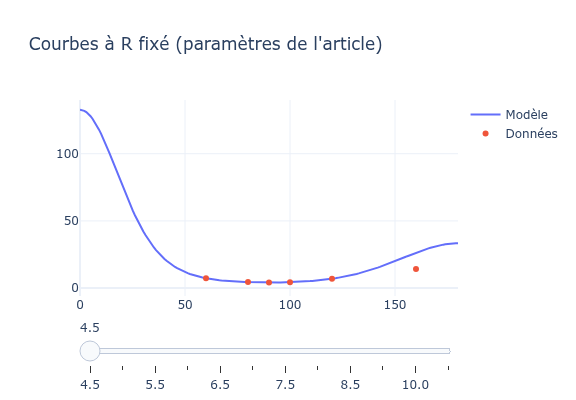

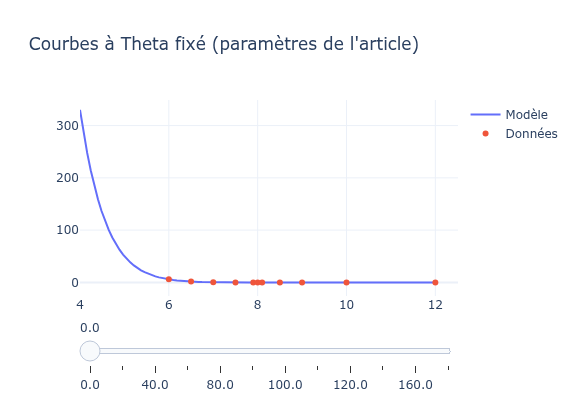

In [21]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_He, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_He, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

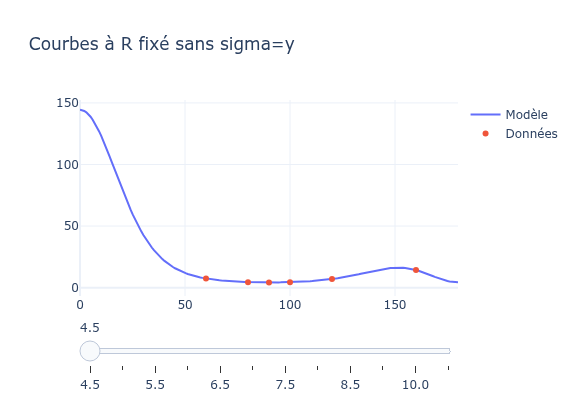

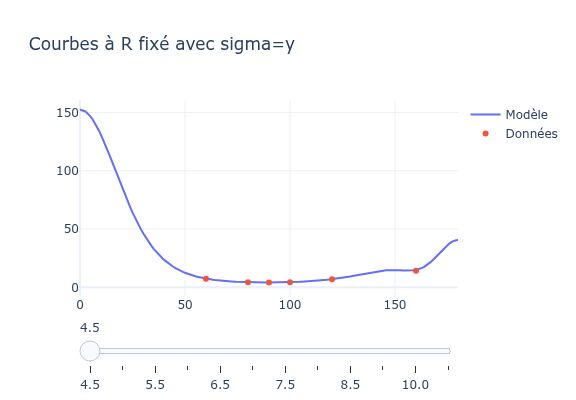

In [22]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

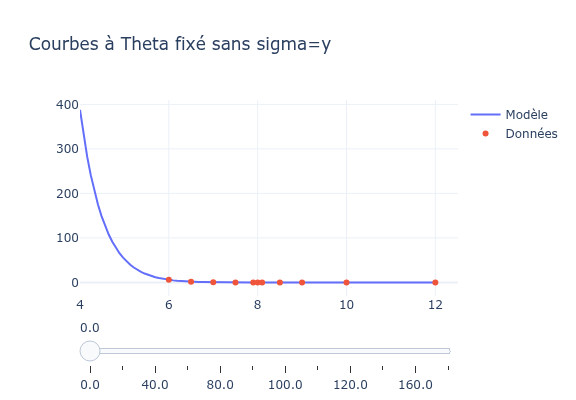

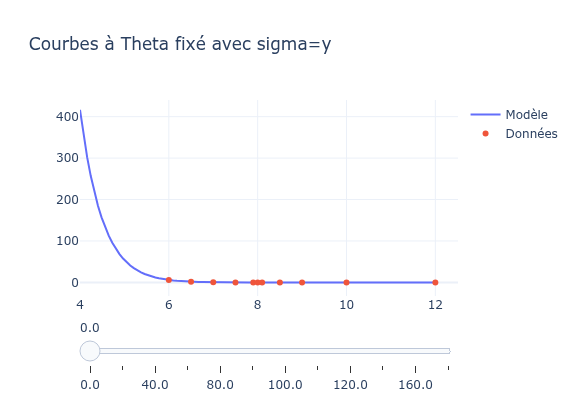

In [23]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, He,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [24]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.026, -0.039,-0.051, -0.063, -0.075, -0.087,
        -0.094, -0.100, -0.112, -0.124, -0.133
    ])
    
    levels_with_labels = levels_to_plot
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)
    
    ax.set_title(f"He-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

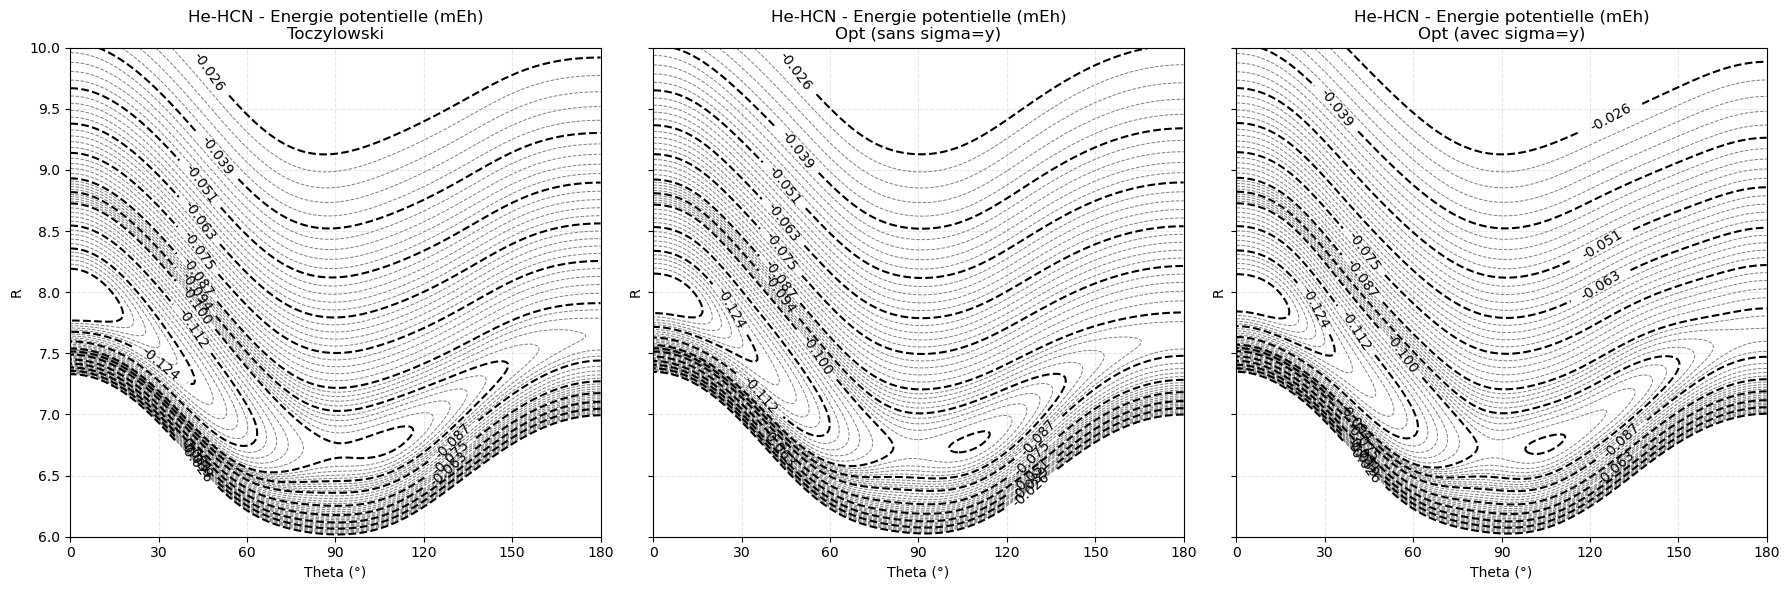

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_He, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Methode 2 : least_squares


In [26]:
def residus_He(params):
    V_pred = V_opt(params, He["R"], He["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - He["Energy_mEh"]).ravel()

In [27]:
result1 = least_squares(residus_He, params_He)
params_opt_ls = result1.x

result2 = least_squares(residus_He, params_He, x_scale = "jac")
params_opt_ls_jac = result2.x

In [32]:
result3 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [40]:
result4 = least_squares(residus_He, params_He, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [46]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R, Theta)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R, Theta)

r2_ls = rsq(V_table_mEh, V_pred_ls)
r2_ls_jac = rsq(V_table_mEh, V_pred_ls_jac)
r2_ls_jac_soft = rsq(V_table_mEh, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(V_table_mEh, V_pred_ls_jac_huber)

rmse_ls = rmse(V_table_mEh, V_pred_ls)
rmse_ls_jac = rmse(V_table_mEh, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(V_table_mEh, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(V_table_mEh, V_pred_ls_jac_huber)

mae_ls = mae(V_table_mEh, V_pred_ls)
mae_ls_jac = mae(V_table_mEh, V_pred_ls_jac)
mae_ls_jac_soft = mae(V_table_mEh, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(V_table_mEh, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

R²                                   : 0.9999979332059865
R²   (x_scale='jac')                 : 0.9999998710239684
R²   (x_scale='jac', 'loss=soft_l1') : 0.9999999004185128
R²   (x_scale='jac', 'loss=huber')   : 0.9999999004185128

rmse                                 : 0.002962097226072788
rmse (x_scale='jac')                 : 0.0007399548431552187
rmse (x_scale='jac', loss='soft_l1') : 0.0006501895959358
rmse (x_scale='jac', loss='huber')   : 0.0006501895959358

mae                                  : 0.001728143407717851
mae  (x_scale='jac')                 : 0.0005812910642023456
mae  (x_scale='jac', loss='soft_l1') : 0.0004947023603499551
mae  (x_scale='jac', loss='huber')   : 0.0004947023603499551


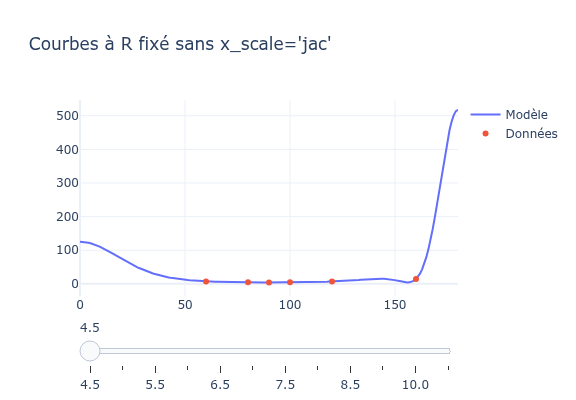

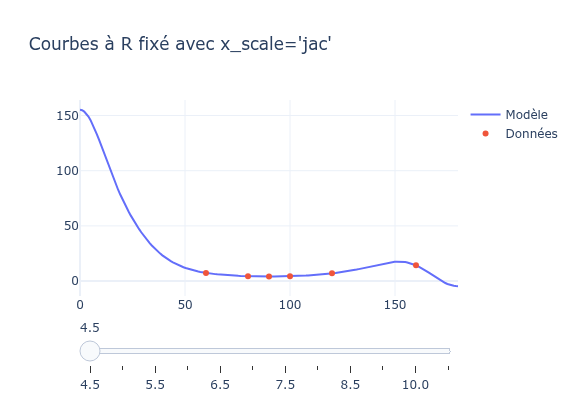

In [29]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

## Variation des params initiaux

In [47]:
def metriques(y, y_pred, params):

  residus = y - y_pred

  rss = np.sum(residus**2)
  tss = np.sum((y - np.mean(y))**2)
  r2 = 1 - rss/tss

  mae = np.mean(np.abs(residus))
  rmse = np.sqrt(np.mean(residus**2))
  param_norm = np.linalg.norm(params)

  return {
      "rmse": rmse,
      "mae": mae,
      "r2": r2,
      "rss": rss,
      "param_norm": param_norm
      }

In [50]:
# import d'un calcul précédent de 'resultats'
with open("resultats_multistart.pkl", "rb") as f:
    resultats = pickle.load(f)

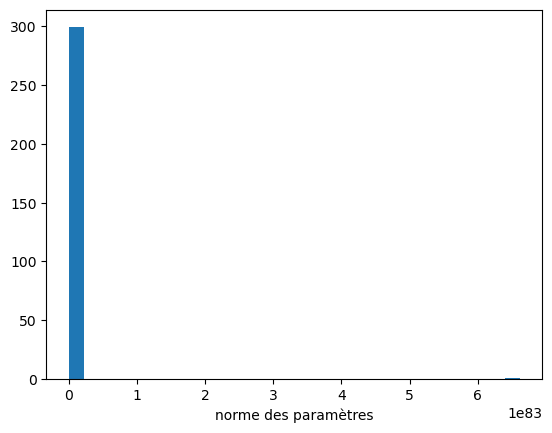

In [51]:
normes = [np.linalg.norm(r["params"]) for r in resultats]

plt.hist(normes, bins=30)
plt.xlabel("norme des paramètres")
plt.show()

In [60]:
# Tri avec rmse
best_rmse_fit = min(resultats, key=lambda r: r["rmse"])
# Solutions stables
bon = [r for r in resultats if r["rmse"] <= 1.10 * best_rmse_fit["rmse"]]

# On récupère tous les "bons" paramètres
params_all = np.array([r["params"] for r in bon])
# On regarde la distribution des paramètres pour
# voir s'ils sont proches
params_std = np.std(params_all, axis=0)

In [64]:
params_std

array([1.22422888e-01, 6.24677012e-03, 2.08147181e-01, 6.70665106e-02,
       8.41819949e-02, 4.10441212e-02, 1.20695347e+02, 1.44986466e+03,
       5.26396360e+02, 2.97351999e+03, 3.33257945e+00, 3.41236717e-01,
       9.78906118e-01, 4.01810366e-01, 4.20271008e-01, 2.37149671e-01,
       9.43362055e+04, 2.52139427e+05, 3.55810426e+05, 2.61096796e+05,
       8.84654462e+04, 2.76885521e+04, 5.95434053e+04, 1.54593800e+05,
       2.17886798e+05, 1.52755117e+05, 4.89316224e+04, 1.46238525e+04,
       1.23602732e+04, 3.33583421e+04, 4.48465231e+04, 2.97012120e+04,
       8.81100250e+03, 2.45570054e+03, 9.43295579e+02, 2.52021802e+03,
       3.06923141e+03, 1.89076775e+03, 5.21061383e+02, 1.34075248e+02])

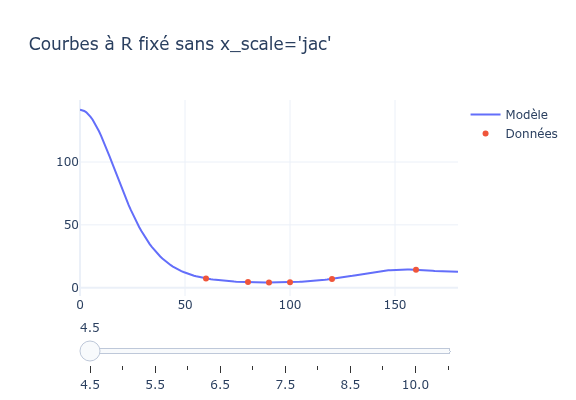

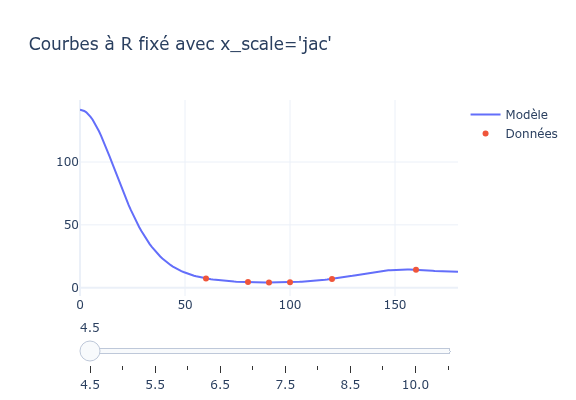

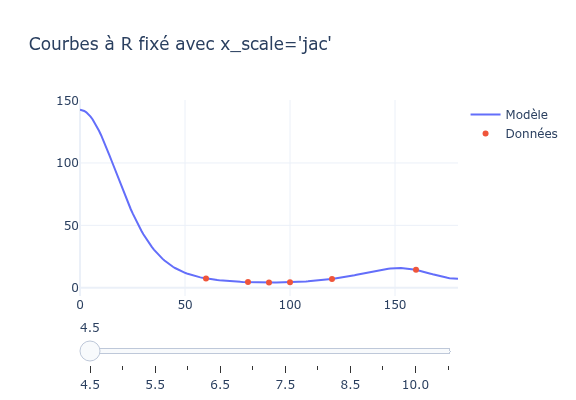

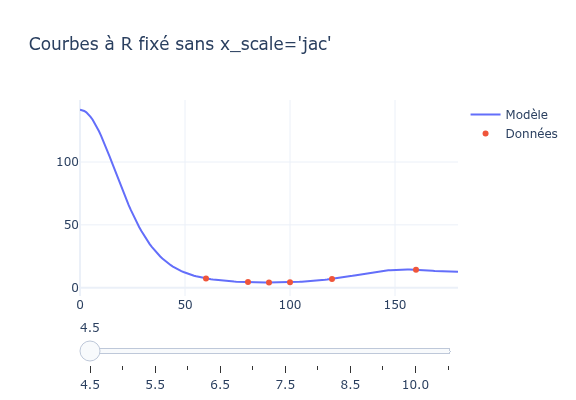

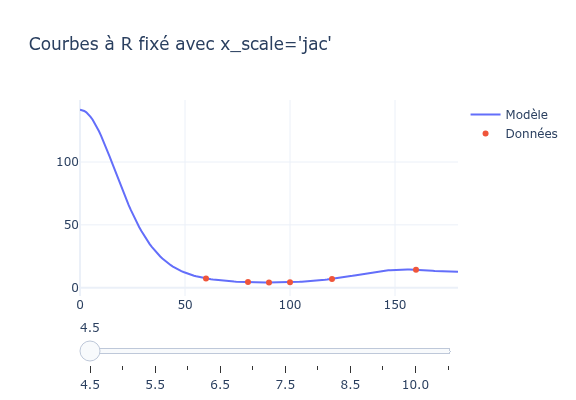

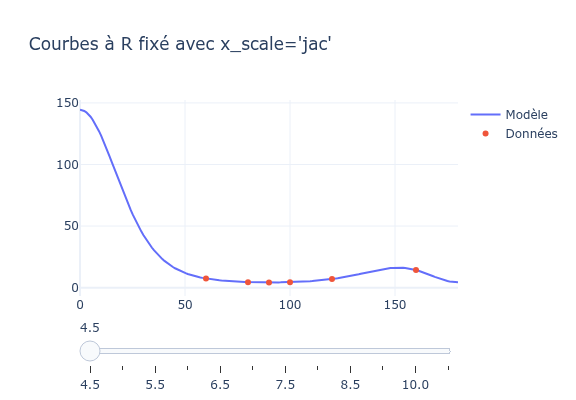

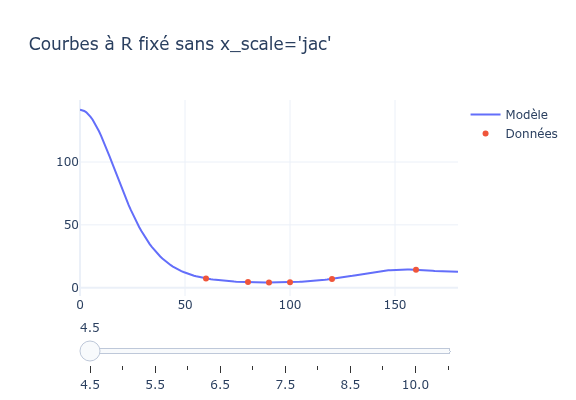

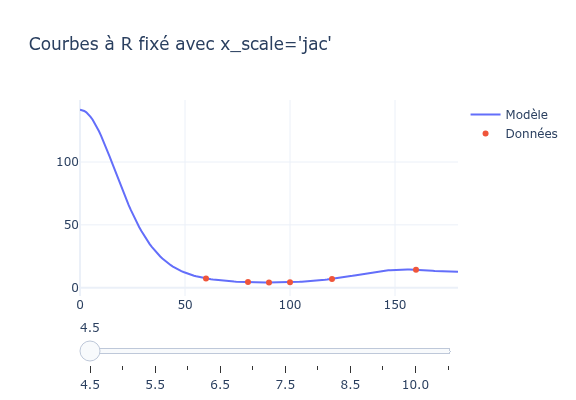

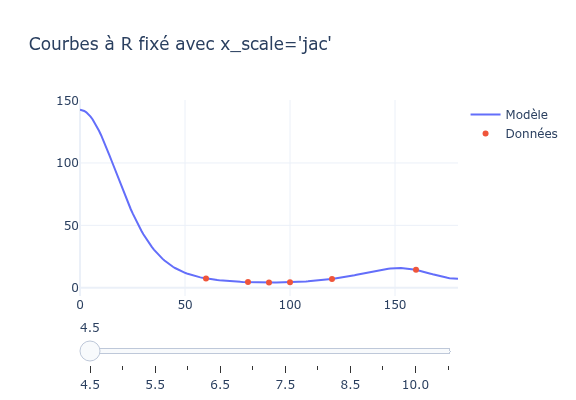

In [63]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_all[0], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_all[1], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")
plot_interactif(V_opt, params_all[2], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")
plot_interactif(V_opt, params_all[3], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_all[4], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")
plot_interactif(V_opt, params_all[5], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")
plot_interactif(V_opt, params_all[6], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_all[7], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")
plot_interactif(V_opt, params_all[8], R_vals, x, He,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")